In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sklearn.linear_model as skl
import imageio
from IPython.display import Image
from tqdm import tqdm

In [2]:
sub = 1
with open(f'../cache/thingseeg2_preproc/regression_weights/sub-{sub:02d}/regress-encode_clip_weights_grayscale.pkl',"rb") as f:
    datadict = pickle.load(f)
    reg_w = datadict['weight'].T
    reg_b = datadict['bias']
print(reg_w.shape, reg_b.shape)

train_latents= np.load('../cache/thingseeg2_extracted_embeddings/train_clip.npy')
test_latents = np.load('../cache/thingseeg2_extracted_embeddings/test_clip.npy')
test_concepts = np.load('../data/thingseeg2_metadata/test_concepts.npy')
print(train_latents.shape, test_latents.shape)

train_latents_mean = np.mean(train_latents,axis=0)
train_latents_std = np.std(train_latents,axis=0)
train_latents_whitened = (train_latents - train_latents_mean) / train_latents_std
test_latents_whitened = (test_latents - train_latents_mean) / train_latents_std
new_w = test_latents @ reg_w
new_w_whitened = test_latents_whitened @ reg_w

# cov_train_latents = np.cov(train_latents, rowvar=False)
# cov_train_latents_whitened = np.cov(train_latents_whitened, rowvar=False)
# print(cov_train_latents_whitened.shape, cov_train_latents.shape)

eeg_train = np.load(f'../data/thingseeg2_preproc/sub-{sub:02d}/train_thingseeg2_avg.npy')
eeg_test = np.load(f'../data/thingseeg2_preproc/sub-{sub:02d}/test_thingseeg2_avg.npy')
eeg_train = eeg_train.reshape(eeg_train.shape[0],-1)
eeg_test = eeg_test.reshape(eeg_test.shape[0],-1)
print(eeg_train.shape, eeg_test.shape)
norm_mean_train = np.mean(eeg_train, axis=0)
norm_scale_train = np.std(eeg_train, axis=0, ddof=1)
eeg_train_whitened = (eeg_train - norm_mean_train) / norm_scale_train
eeg_test_whitened = (eeg_test - norm_mean_train) / norm_scale_train

pred_latents = np.load(f'../cache/thingseeg2_preproc/predicted_embeddings/sub-{sub:02d}/regress_clip_grayscale.npy')
pred_latents_whitened = (pred_latents - train_latents_mean) / train_latents_std
new_w_pred = pred_latents @ reg_w
new_w_pred_whitened = pred_latents_whitened @ reg_w
print(new_w_pred.shape, new_w_pred_whitened.shape)

(1024, 1360) (1360,)
(16540, 1024) (200, 1024)
(16540, 1360) (200, 1360)
(200, 1360) (200, 1360)


In [ ]:
from scipy.spatial.distance import pdist, squareform
dist_test_latents = pdist(test_latents, metric='euclidean')
dist_test_latents_whitened = pdist(test_latents_whitened, metric='euclidean')
print(dist_test_latents.shape, dist_test_latents_whitened.shape)
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
# hierarchical_cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
linkage_data = linkage(dist_test_latents_whitened, method='ward', metric='euclidean')
print(linkage_data.shape)
leaves = leaves_list(linkage_data)
labels = [f"{leaf}-{test_concepts[leaf]}" for leaf in range(len(leaves))]

(19900,) (19900,)
(199, 4)


In [4]:
np.save('../misc/clip_ordering.npy', leaves)

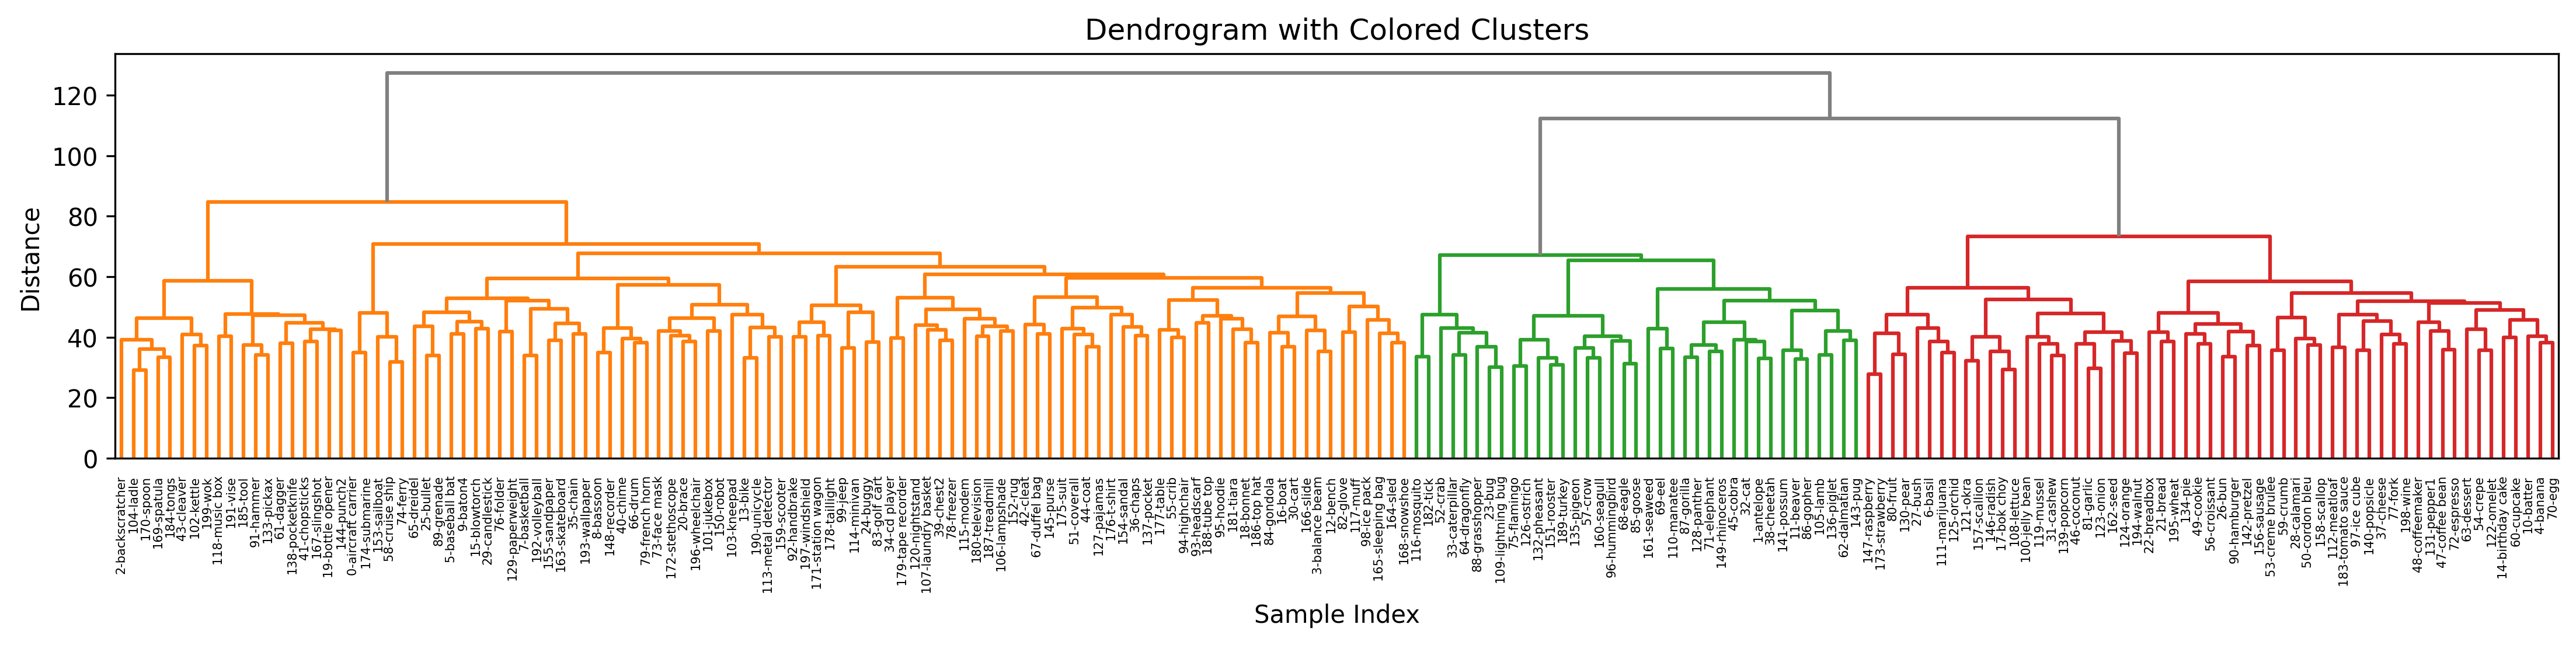

Cluster 1: 106 leaves
Cluster 2: 37 leaves
Cluster 3: 57 leaves


In [5]:
from scipy.cluster.hierarchy import dendrogram, fcluster

# Assuming linkage_data is a numpy array representing the linkage matrix
# Plot the dendrogram and color the clusters
plt.figure(figsize=(18, 3), dpi=300) # 300
dendro = dendrogram(linkage_data, color_threshold=0.7 * max(linkage_data[:, 2]), above_threshold_color='grey', labels=labels)
plt.title('Dendrogram with Colored Clusters')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# Extract the cluster labels
max_d = 0.7 * max(linkage_data[:, 2])  # Adjust this threshold as needed
cluster_labels = fcluster(linkage_data, max_d, criterion='distance')

# Count the number of leaves in each cluster
unique_clusters, counts = np.unique(cluster_labels, return_counts=True)

# Print the number of leaves in each cluster
for cluster, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster}: {count} leaves")

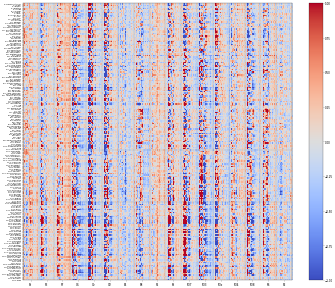

In [6]:
plt.figure(figsize=(15*1.5, 12*1.5), dpi=20) # 300

plt.imshow(new_w_pred_whitened[leaves], cmap='coolwarm', vmin=-1, vmax=1, aspect=7, interpolation='none')


num_electrodes = 17
xtick_positions = np.linspace(0, reg_w.shape[1] - 80, num_electrodes) + 40
xtick_labels = ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']
# Set the x-ticks to represent 17 electrodes
plt.xticks(xtick_positions, xtick_labels)

num_classes = 200
ytick_positions = np.linspace(-0.5, new_w_pred_whitened.shape[0]-1.5, num_classes) + 0.5
ytick_labels = test_concepts[leaves]
# Add index number in front of each label
ytick_labels = [f"{i}: {label}" for i, label in enumerate(ytick_labels)]
# Set the y-ticks to represent 200 classes
plt.yticks(ytick_positions, ytick_labels, fontsize=7)

for i in range(0, reg_w.shape[1], 80):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.4)
for i in [106, 106+37]:
    plt.axhline(y=i, color='black', linestyle='--', linewidth=0.4)


plt.colorbar()
plt.show()

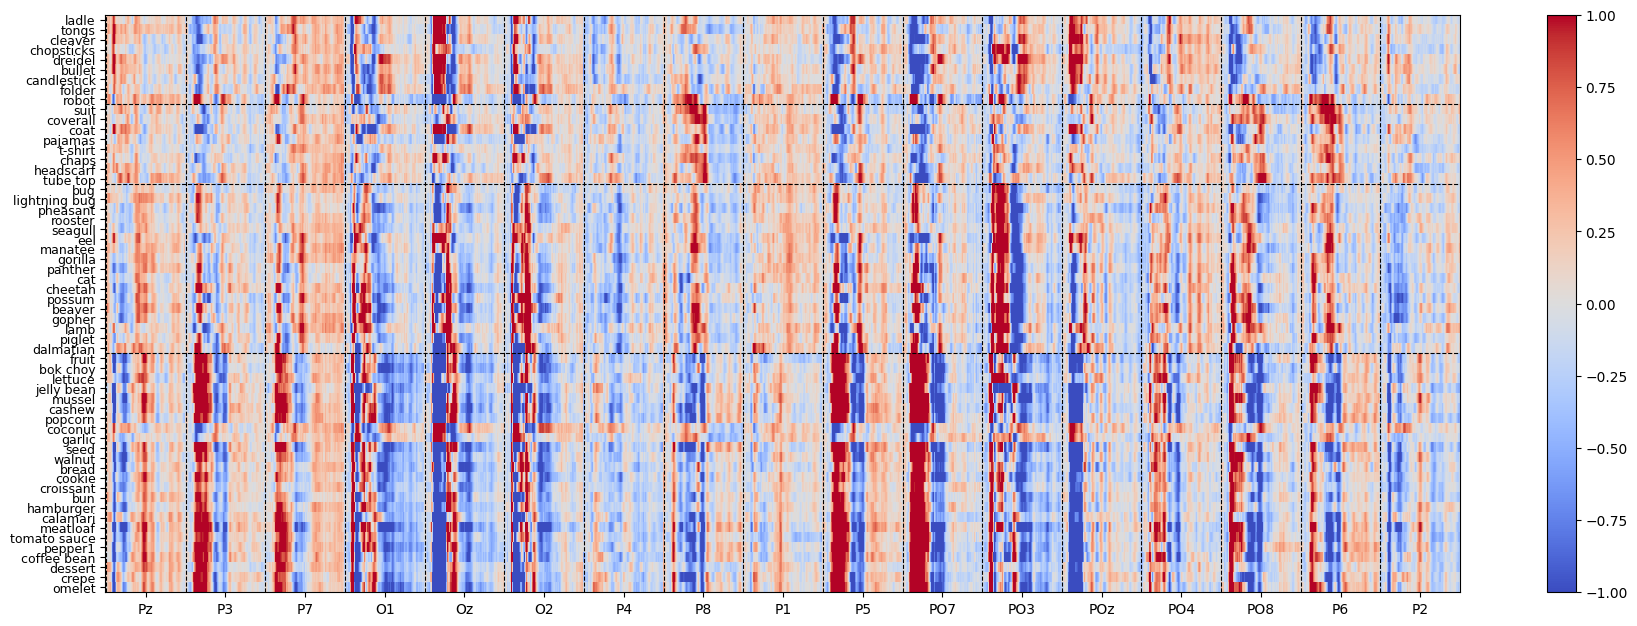

In [7]:
patterns = new_w_pred_whitened[leaves]
ytick_labels = test_concepts[leaves]
# ytick_labels = [f"{i}: {label}" for i, label in enumerate(ytick_labels)]
# Indices of rows to delete
rows_to_delete = [0, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 82, 84, 85, 86, 87, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 114, 115, 118, 119, 120, 122, 123, 124, 125, 130, 131, 132, 134, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 162, 164, 166, 168, 169, 174, 175, 176, 177, 179, 180, 183, 184, 185, 186, 187, 188, 191, 195, 196, 197, 198, 199]
# Delete the specified rows
patterns = np.delete(patterns, rows_to_delete, axis=0)
ytick_labels = np.delete(ytick_labels, rows_to_delete, axis=0)
# ytick_labels = [f"{i}: {label}" for i, label in enumerate(ytick_labels)]


plt.figure(figsize=(15*1.5, 5*1.5), dpi=100) # 300

plt.imshow(patterns, cmap='coolwarm', vmin=-1, vmax=1, aspect=10, interpolation='none')


num_electrodes = 17
xtick_positions = np.linspace(0, reg_w.shape[1] - 80, num_electrodes) + 40
xtick_labels = ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']
# Set the x-ticks to represent 17 electrodes
plt.xticks(xtick_positions, xtick_labels)

num_classes = len(ytick_labels)
ytick_positions = np.linspace(-0.5, patterns.shape[0]-1.5, num_classes) + 0.5

# Set the y-ticks to represent 200 classes
plt.yticks(ytick_positions, ytick_labels, fontsize=9)

for i in range(0, reg_w.shape[1], 80):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.8)
for i in [8, 16, 33]:
    plt.axhline(y=i+0.5, color='black', linestyle='--', linewidth=0.8)


plt.colorbar()
plt.show()

In [8]:
new_w_pred_whitened_list = []
train_latents= np.load('../cache/thingseeg2_extracted_embeddings/train_clip.npy')
test_latents = np.load('../cache/thingseeg2_extracted_embeddings/test_clip.npy')
test_concepts = np.load('../data/thingseeg2_metadata/test_concepts.npy')
for sub in tqdm(range(1, 11)):
    with open(f'../cache/thingseeg2_preproc/regression_weights/sub-{sub:02d}/regress-encode_clip_weights_grayscale.pkl',"rb") as f:
        datadict = pickle.load(f)
        reg_w = datadict['weight'].T
        reg_b = datadict['bias']
    # print(reg_w.shape, reg_b.shape)
    # print(train_latents.shape, test_latents.shape)

    train_latents_mean = np.mean(train_latents,axis=0)
    train_latents_std = np.std(train_latents,axis=0)
    train_latents_whitened = (train_latents - train_latents_mean) / train_latents_std
    test_latents_whitened = (test_latents - train_latents_mean) / train_latents_std
    new_w = test_latents @ reg_w
    new_w_whitened = test_latents_whitened @ reg_w

    # cov_train_latents = np.cov(train_latents, rowvar=False)
    # cov_train_latents_whitened = np.cov(train_latents_whitened, rowvar=False)
    # print(cov_train_latents_whitened.shape, cov_train_latents.shape)

    eeg_train = np.load(f'../data/thingseeg2_preproc/sub-{sub:02d}/train_thingseeg2_avg.npy')
    eeg_test = np.load(f'../data/thingseeg2_preproc/sub-{sub:02d}/test_thingseeg2_avg.npy')
    eeg_train = eeg_train.reshape(eeg_train.shape[0],-1)
    eeg_test = eeg_test.reshape(eeg_test.shape[0],-1)
    # print(eeg_train.shape, eeg_test.shape)
    norm_mean_train = np.mean(eeg_train, axis=0)
    norm_scale_train = np.std(eeg_train, axis=0, ddof=1)
    eeg_train_whitened = (eeg_train - norm_mean_train) / norm_scale_train
    eeg_test_whitened = (eeg_test - norm_mean_train) / norm_scale_train

    pred_latents = np.load(f'../cache/thingseeg2_preproc/predicted_embeddings/sub-{sub:02d}/regress_clip_grayscale.npy')
    pred_latents_whitened = (pred_latents - train_latents_mean) / train_latents_std
    new_w_pred = pred_latents @ reg_w
    new_w_pred_whitened = pred_latents_whitened @ reg_w
    new_w_pred_whitened_list.append(new_w_pred_whitened)
    # print(new_w_pred.shape, new_w_pred_whitened.shape)
new_w_pred_whitened_array = np.array(new_w_pred_whitened_list)
new_w_pred_whitened_mean = np.mean(new_w_pred_whitened_array, axis=0)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:11<00:00,  1.20s/it]


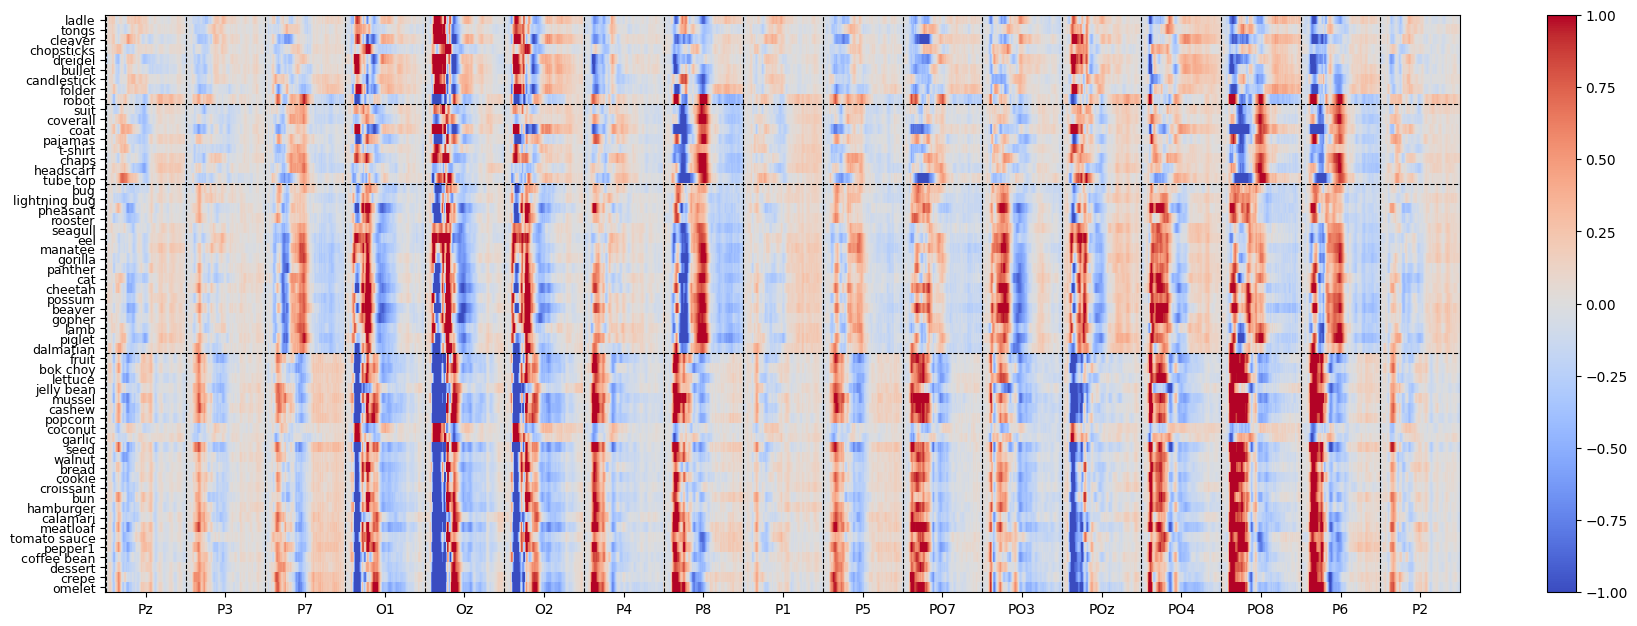

In [9]:
patterns = new_w_pred_whitened_mean[leaves]
ytick_labels = test_concepts[leaves]
# ytick_labels = [f"{i}: {label}" for i, label in enumerate(ytick_labels)]
# Indices of rows to delete
rows_to_delete = [0, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 82, 84, 85, 86, 87, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 114, 115, 118, 119, 120, 122, 123, 124, 125, 130, 131, 132, 134, 142, 143, 144, 146, 147, 148, 149, 150, 151, 152, 153, 162, 164, 166, 168, 169, 174, 175, 176, 177, 179, 180, 183, 184, 185, 186, 187, 188, 191, 195, 196, 197, 198, 199]
# Delete the specified rows
patterns = np.delete(patterns, rows_to_delete, axis=0)
ytick_labels = np.delete(ytick_labels, rows_to_delete, axis=0)
# ytick_labels = [f"{i}: {label}" for i, label in enumerate(ytick_labels)]


plt.figure(figsize=(15*1.5, 5*1.5), dpi=100) # 300

plt.imshow(patterns, cmap='coolwarm', vmin=-1, vmax=1, aspect=10, interpolation='none')


num_electrodes = 17
xtick_positions = np.linspace(0, reg_w.shape[1] - 80, num_electrodes) + 40
xtick_labels = ['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2']
# Set the x-ticks to represent 17 electrodes
plt.xticks(xtick_positions, xtick_labels)

num_classes = len(ytick_labels)
ytick_positions = np.linspace(-0.5, patterns.shape[0]-1.5, num_classes) + 0.5

# Set the y-ticks to represent 200 classes
plt.yticks(ytick_positions, ytick_labels, fontsize=9)

for i in range(0, reg_w.shape[1], 80):
    plt.axvline(x=i, color='black', linestyle='--', linewidth=0.8)
for i in [8, 16, 33]:
    plt.axhline(y=i+0.5, color='black', linestyle='--', linewidth=0.8)


plt.colorbar()
plt.show()